# Clustering of Ausgrid Energy Consumption Data

This notebook clusters individual household energy consumers from the **Ausgrid** dataset (2010–2013) to identify groups with distinct daily usage patterns.

> **Note:** The full dataset file `Ausgrid_2010_2013_Orange_Combined.csv` is **not included in this repository** due to its large size. If you want to recreate it simply use all the induvidual datasets in Datasorted by user and create a new csv file whith a separate consumption of each user in each row (look at the data.head() in the notebook under input data for example)

## Dataset

The Ausgrid dataset contains half-hourly energy consumption records for residential consumers in New South Wales, Australia. For these experiments we use **300 users** from the dataset.

## What this notebook does

1. **Loads and reshapes the data** — pivots the long-format CSV into a wide DataFrame (timestamps × users), resamples to hourly resolution, and computes mean weekly profiles for three day types: weekday, Saturday, and Sunday. Each user is represented as a 72-dimensional feature vector.

2. **Normalises profiles** — divides each profile by its daily maximum so that shape rather than magnitude drives the clustering.

3. **Compares clustering methods** — runs KMeans, Agglomerative (Ward linkage), and GMM with the same number of clusters each, and evaluates them on four criteria: centroid RMSE, Silhouette score, Calinski-Harabasz index, and Davies-Bouldin index.

4. **Selects the best method** — KMeans is chosen based on the overall ranking across all metrics, and this result is consistent across different numbers of clusters.

5. **Saves results** — exports `user_ids_sorted_by_cluster.csv` ranking every user by their distance to their cluster centroid.

# LIBS

In [115]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import os

%matplotlib inline
mpl.rcParams['figure.facecolor'] = "w"

# FUNCTIONS

In [116]:
def reshape2threedays(df_in):
    """
    DESCRIPTION: Reshapes input dataframe with hourly resolution to a dataframe, 
                 where every consumer has a weekly mean profile in each row. 
    
    Input:
    df_in (pd.DataFrame): Dataframe holding time series data with hourly resolution in every column. Indices are timestamps.
    
    Output:
    df (pd.DataFrame): Dataframe holding time series data with daily resolution and hours in every columns.
    
    """
    df = df_in.copy()
    df.columns.name = "ts_id"
    df.index.name = "timestamp"
    df = df.unstack().reset_index()
    
    # 0 = weekdays, 5 = Saturday, 6 = Sunday
    dayofweek = df.timestamp.dt.dayofweek
    days = dayofweek.where(dayofweek >= 5, 0).rename("dayofweek")
    
    df = (pd.pivot_table(df, 
                         values=0, 
                         index=df.ts_id,
                         columns=[days, 
                                  df.timestamp.rename("hour").dt.hour]
                         )
            .round(3)
         )
    return df


def normalize_df(df):
    """
    DESCRIPTION: Normalizes input dataframe according to daily maximum.
    """
    # fillna is for profiles with only zeros per day
    return df.apply(lambda s: s / df.max(axis=1)).fillna(0)

    
    
def plot_clustered_profiles(df, clust, n_cols=3, alpha=0.2):
    """
    DESCRIPTION: Plots one subplot per cluster, where each subplot contains
                    all profiles in a particular cluster together with a cluster centroid.
                    Noise points (label -1, e.g. from DBSCAN) are automatically excluded.

    Input:
    df (pd.DataFrame): Normalised weekly-mean profiles (one row per consumer).
    clust (pd.Series): Cluster labels aligned to df's index.
    n_cols (int): Number of subplot columns.
    alpha (float): Transparency for individual profiles.
    """
    # Exclude noise points (label == -1, e.g. produced by DBSCAN)
    n_noise = (clust == -1).sum()
    clust = clust[clust != -1]
    df = df.loc[clust.index]

    clust_perc = 100 * clust.value_counts(normalize=True)

    n_rows = int(np.ceil(clust.nunique() / n_cols))
    fontsize = 15
    x_axis = ["Week day", "Saturdays", "Sundays"]

    fig = plt.figure(figsize=[15, n_rows*4])

    if n_noise > 0:
        fig.suptitle(f"Note: {n_noise} noise point(s) (label -1) excluded from plot",
                     fontsize=11, color="red", y=1.01)

    for i, clust_n in enumerate(clust_perc.index):

        ax = fig.add_subplot(n_rows, n_cols, i+1)
        df_plot = df[clust == clust_n]
        
        step = 10 if df_plot.shape[0] > 500 else 1  # plot less profiles

        plt.plot(df_plot.iloc[::step].T.values, alpha=alpha, color="dodgerblue")
        df_plot.mean().plot(ax=plt.gca(), alpha=1, color="k", legend=False);

        plt.title("clust: {}, perc: {:.1f}%".format(clust_n, 
                                                    clust_perc.loc[clust_n]), 
                                                    fontsize=fontsize+5);
        plt.xticks(np.arange(0, 72, 24), x_axis, fontsize=12);
        plt.yticks(np.arange(0, 1.1, 0.1), fontsize=fontsize);

        plt.xlabel("Hours", fontsize=fontsize)
        plt.ylabel("$P/P_{max}$", fontsize=fontsize)
        plt.grid()
        plt.ylim(0, 1)

    plt.tight_layout()


# 0. INPUT DATA

In [117]:
# DATA PATH
base_dir = os.getcwd()
csv_path = os.path.join(base_dir, "Ausgrid_2010_2013_Orange_Combined.csv")

# LOAD LONG-FORMAT AUSGRID DATA
raw = pd.read_csv(
    csv_path,
    usecols=["Timestamp_UTC", "UserID", "Energy_Consumption"],
)
raw["Timestamp_UTC"] = pd.to_datetime(raw["Timestamp_UTC"], utc=True).dt.tz_localize(None)

# KEEP ONLY 300 USERS
n_users = 300
selected_users = np.sort(raw["UserID"].dropna().unique())[:n_users]
if selected_users.size < n_users:
    raise ValueError(f"Requested {n_users} users, but dataset has only {selected_users.size} users.")

raw = raw[raw["UserID"].isin(selected_users)]

# PIVOT TO WIDE FORMAT (timestamp index, one column per user)
data = (
    raw.pivot_table(
        index="Timestamp_UTC",
        columns="UserID",
        values="Energy_Consumption",
        aggfunc="mean",
    )
    .sort_index()
    .astype(np.float32)
    .fillna(0.0)
)
data.columns = [f"user_{int(c)}" for c in data.columns]

print(f"Using {data.shape[1]} users and {data.shape[0]} timestamps from {os.path.basename(csv_path)}")

Using 300 users and 52608 timestamps from Ausgrid_2010_2013_Orange_Combined.csv


The original Ausgrid file is in long format (`Timestamp_UTC`, `UserID`, `Energy_Consumption`). We pivot it into DataFrame `data` with timestamps as index and one column per user, and then keep 300 users for clustering experiments.

In [118]:
data.shape

(52608, 300)

In [119]:
data.head()

,user_1,user_2,user_3,user_4,user_5,user_6,user_7,user_8,user_9,user_10,...,user_291,user_292,user_293,user_294,user_295,user_296,user_297,user_298,user_299,user_300
Timestamp_UTC,,,,,,,,,,,,,,,,,,,,,
2010-07-01 00:30:00,0.303,0.085,0.669,0.075,0.0,0.044,0.093,0.124,0.033,0.031,...,0.398,0.044,0.006,0.102,0.059,0.019,0.205,0.096,1.464,0.279
2010-07-01 01:00:00,0.471,0.142,0.671,0.086,0.0,0.041,0.100,0.088,0.019,0.051,...,0.413,0.056,0.000,0.203,0.062,0.048,0.106,0.110,1.413,0.924
2010-07-01 01:30:00,0.083,0.082,0.675,0.085,0.0,0.047,0.090,0.150,0.008,0.052,...,0.276,0.588,0.009,0.236,0.037,0.030,0.169,0.080,1.428,0.803
2010-07-01 02:00:00,0.121,0.119,0.683,0.084,0.0,0.046,0.051,0.097,0.009,0.043,...,0.307,0.069,0.000,0.160,0.081,0.019,0.270,0.105,1.445,0.066
2010-07-01 02:30:00,0.361,0.105,0.694,0.084,0.0,0.047,0.148,0.115,0.009,0.026,...,0.264,0.031,0.008,0.176,0.041,0.018,0.255,0.089,1.407,0.089


# 1. Clustering with KMeans

In [120]:
X_weekly_mean = reshape2threedays(data.resample("1h").mean())

X_weekly_mean_norm = normalize_df(X_weekly_mean)
print("X_weekly_mean_norm shape:", X_weekly_mean.shape)

n_clusters = 10
model = KMeans(n_clusters).fit(X_weekly_mean_norm.values)
clust = pd.Series(model.labels_, index=X_weekly_mean_norm.index)

X_weekly_mean_norm shape: (300, 72)


As you can see below, time series in a dataset have different daily behaviours.

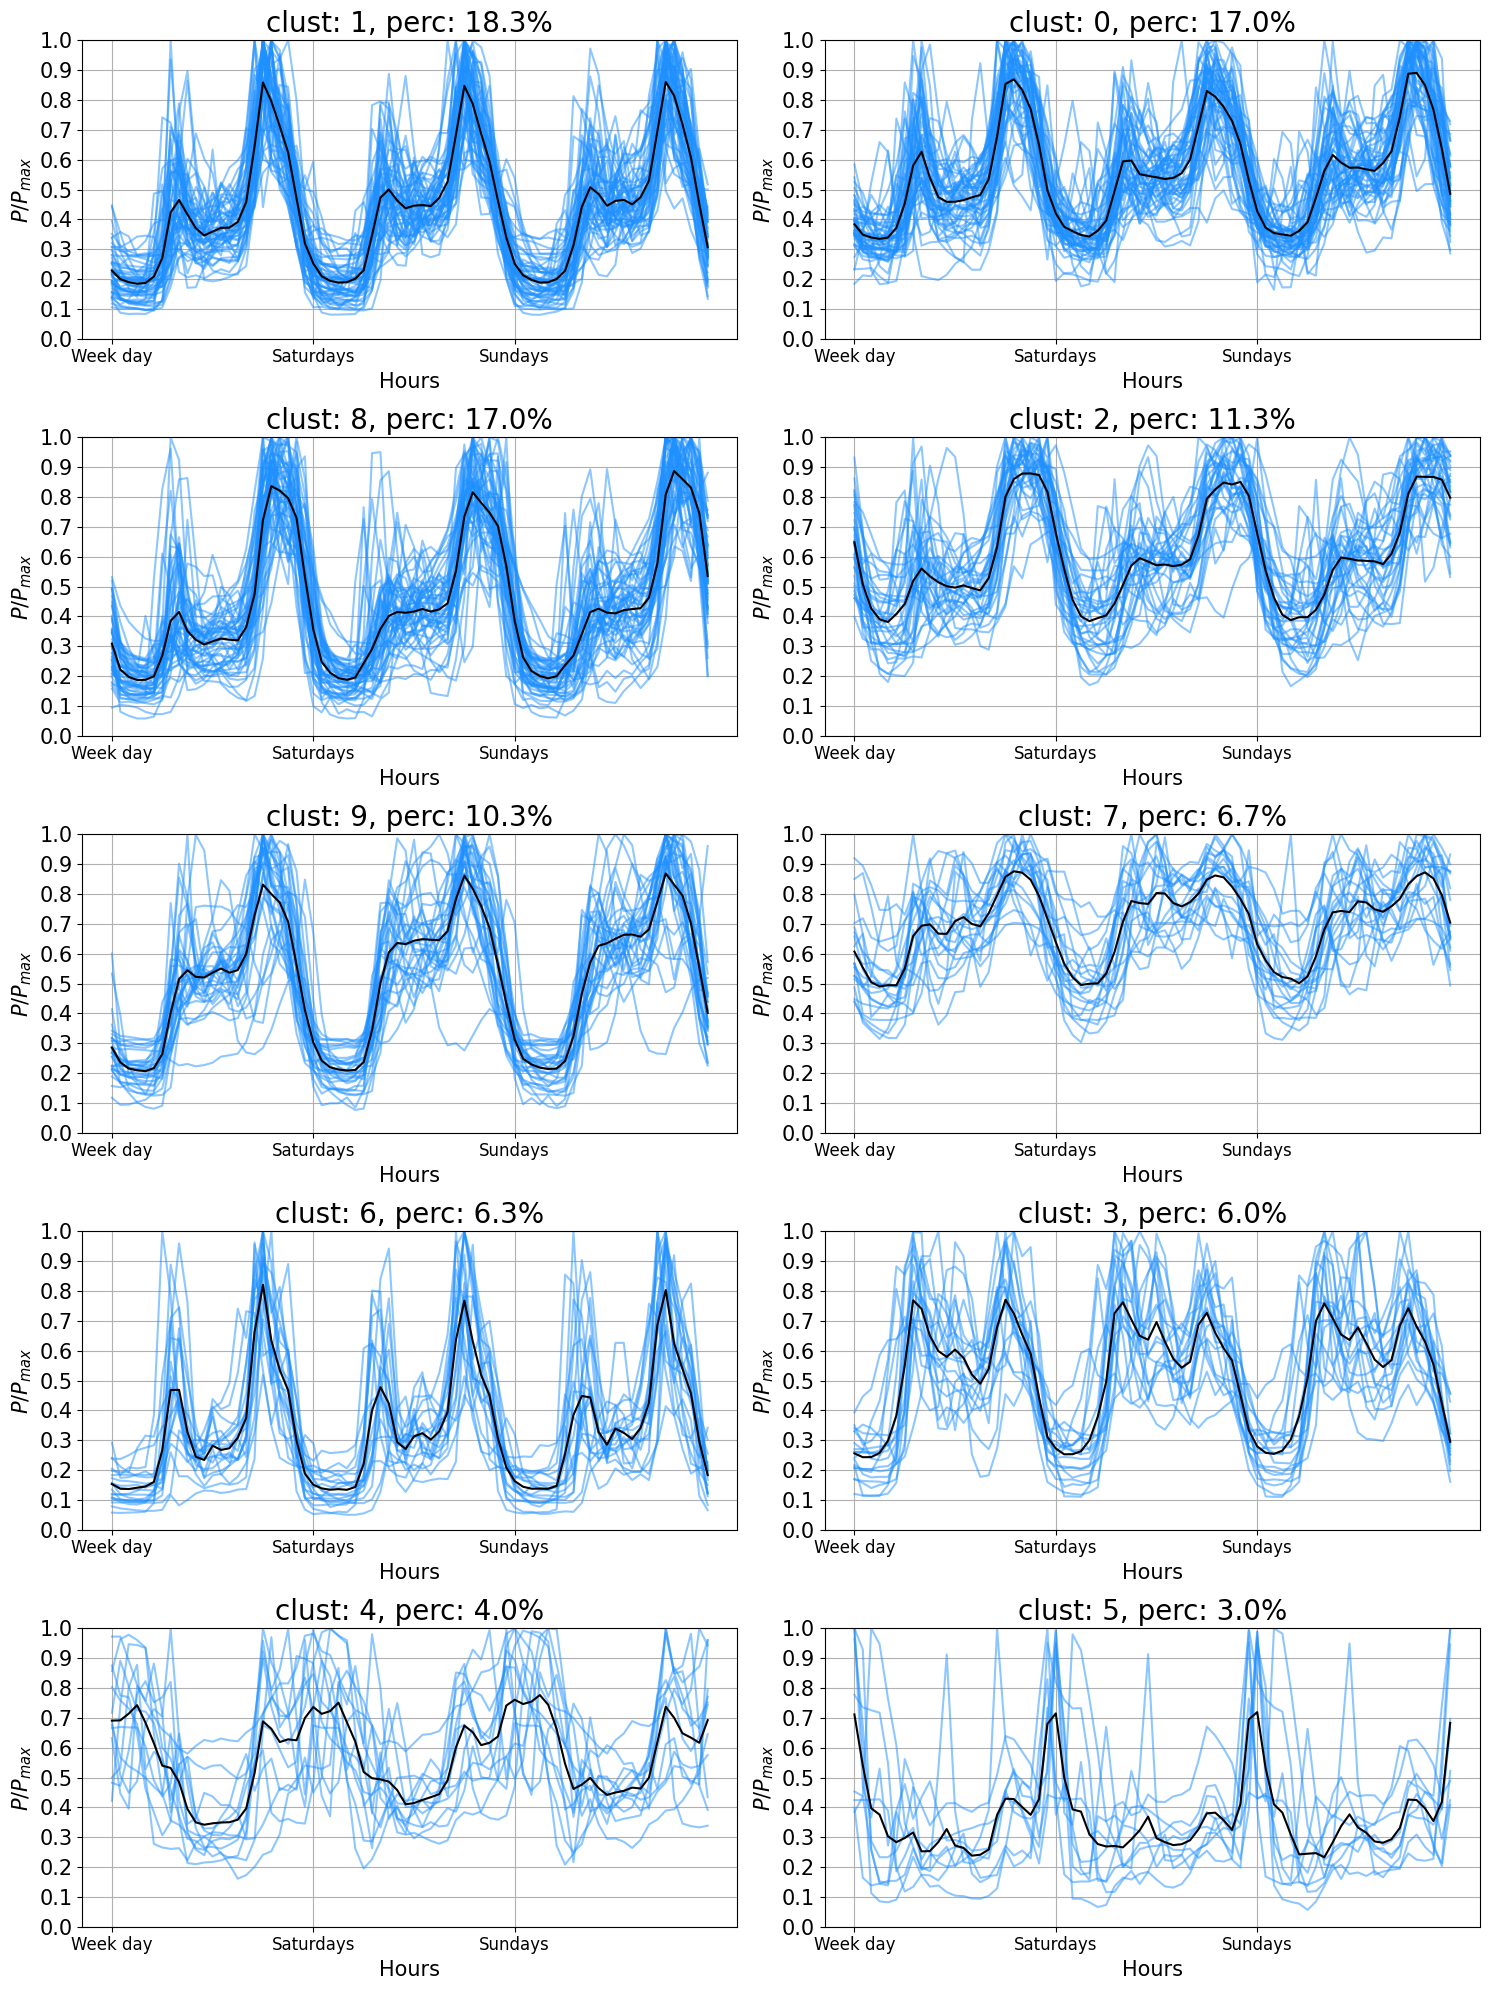

In [121]:
plot_clustered_profiles(X_weekly_mean_norm, clust, n_cols=2, alpha=0.5);

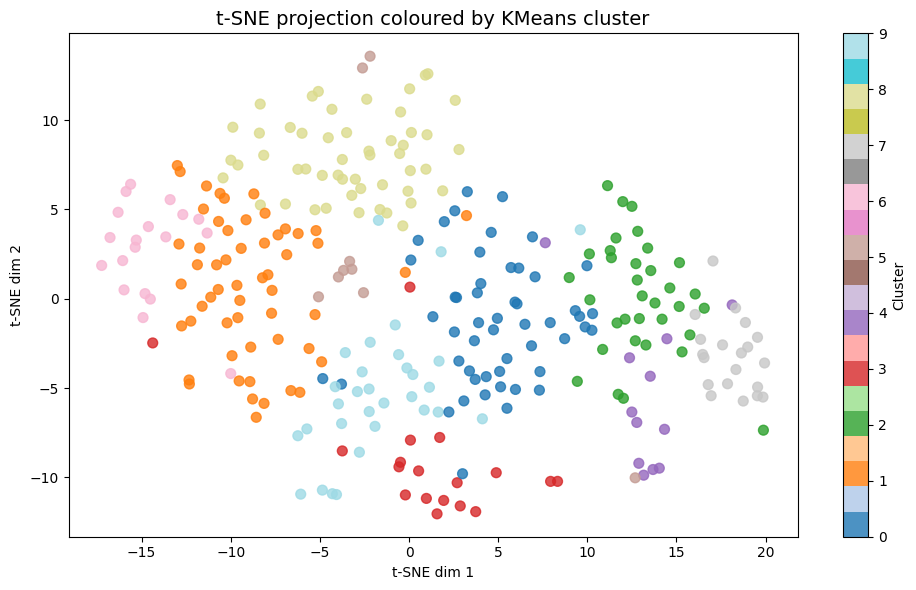

In [122]:
from sklearn.manifold import TSNE

# Compute t-SNE 2D projection of normalised weekly profiles
tsne_results = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_weekly_mean_norm.values)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    tsne_results[:, 0], tsne_results[:, 1],
    c=clust.values, cmap="tab20", alpha=0.8, s=50
)
plt.colorbar(sc, ax=ax, label="Cluster")
ax.set_title("t-SNE projection coloured by KMeans cluster", fontsize=14)
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
plt.tight_layout()
plt.show()

# 2. Clustering with Agglomerative (Ward)

In [123]:
from sklearn.cluster import AgglomerativeClustering

# Linkage determines how distance between clusters is measured
model_agglo = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward').fit(X_weekly_mean_norm.values)
agglo_labels = model_agglo.labels_


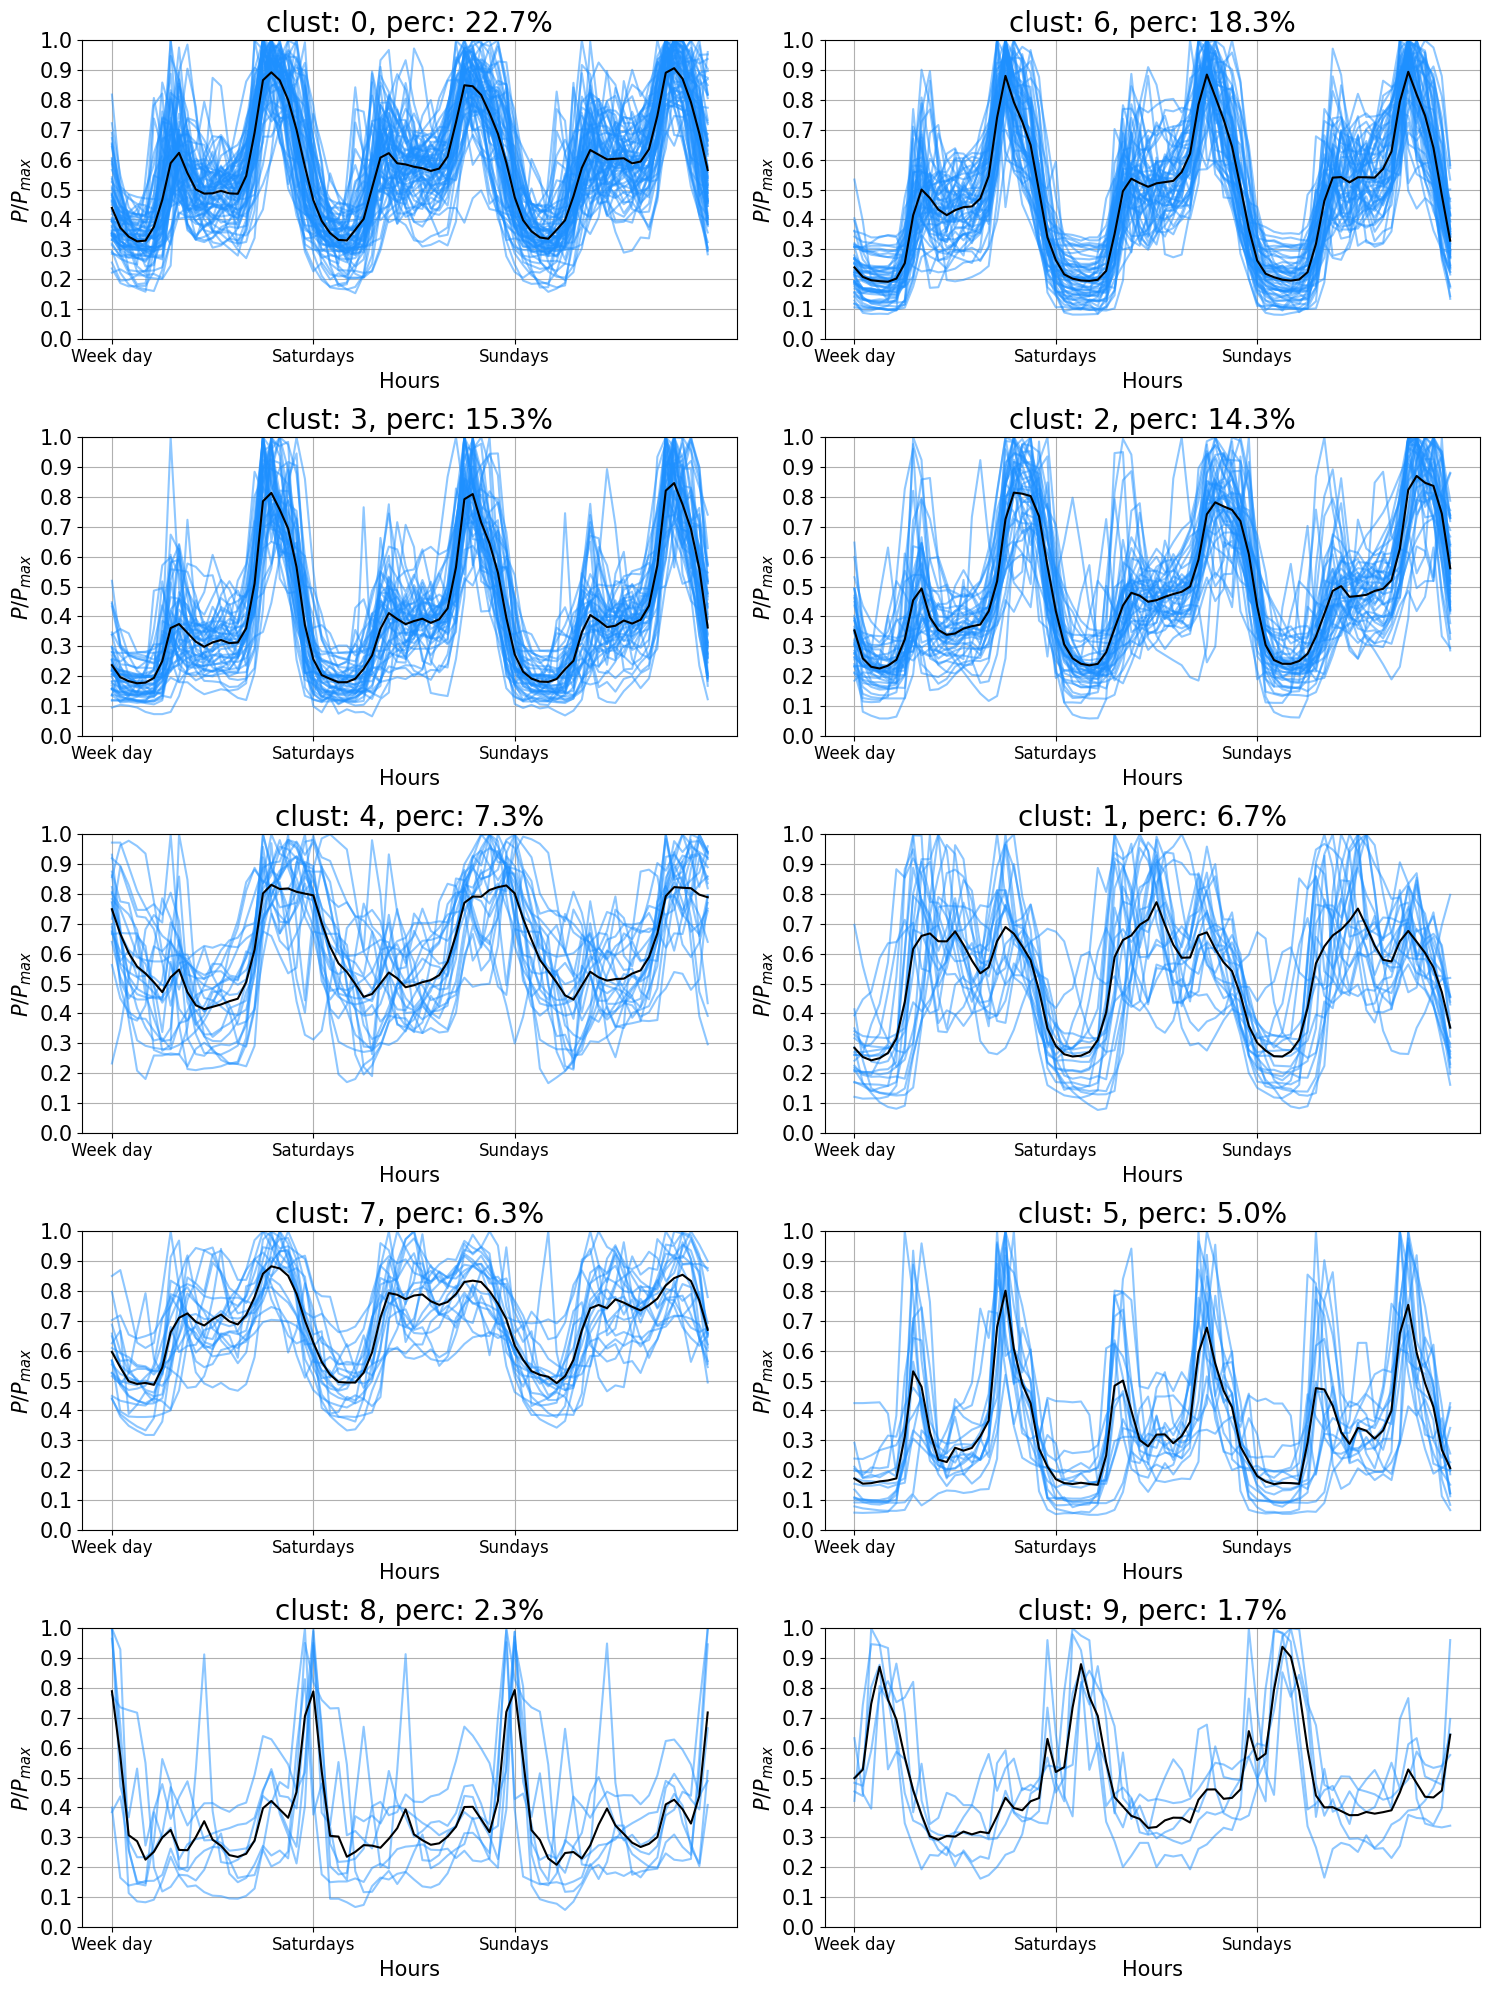

In [124]:
clust_agglo = pd.Series(agglo_labels, index=X_weekly_mean_norm.index)
plot_clustered_profiles(X_weekly_mean_norm, clust_agglo, n_cols=2, alpha=0.5)


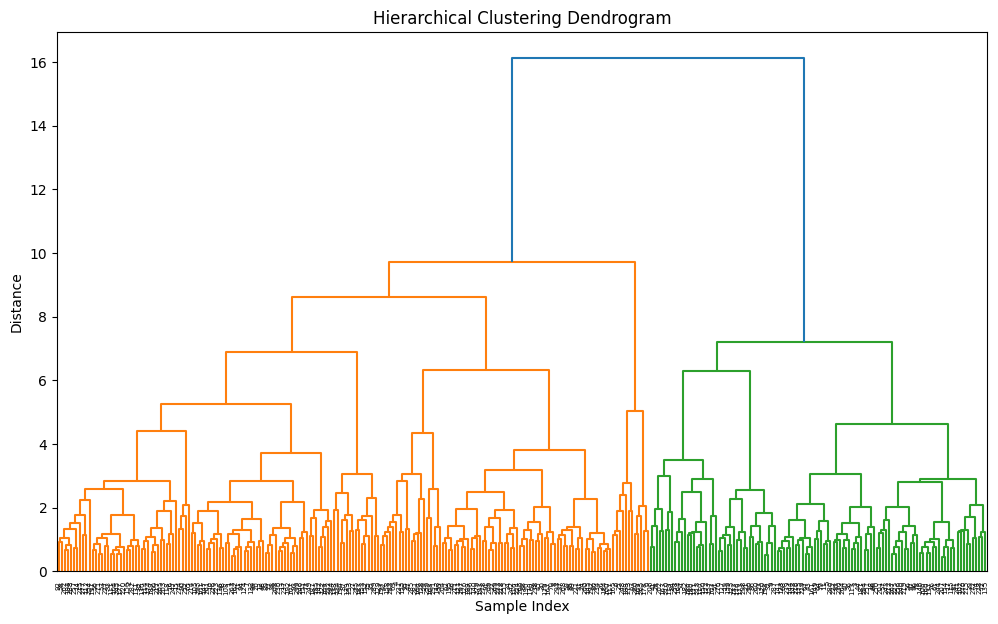

In [125]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Calculate the linkage matrix
linked = linkage(X_weekly_mean_norm.values, 'ward')

plt.figure(figsize=(12, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

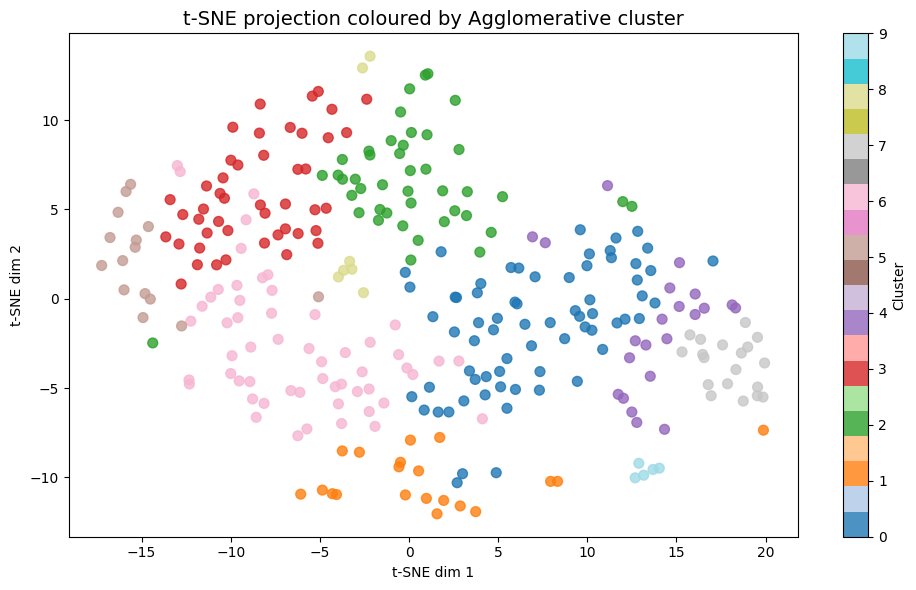

In [126]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    tsne_results[:, 0], tsne_results[:, 1],
    c=agglo_labels, cmap="tab20", alpha=0.8, s=50
)
plt.colorbar(sc, ax=ax, label="Cluster")
ax.set_title("t-SNE projection coloured by Agglomerative cluster", fontsize=14)
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
plt.tight_layout()
plt.show()

# 3. Clustering with GMM

In [127]:
from sklearn.mixture import GaussianMixture

# covariance_type 'full' allows for elliptical clusters
model_gmm = GaussianMixture(n_components=n_clusters, covariance_type='full').fit(X_weekly_mean_norm.values)

# You can get the hard labels or the probabilities
gmm_labels = model_gmm.predict(X_weekly_mean_norm.values)
probs = model_gmm.predict_proba(X_weekly_mean_norm.values)


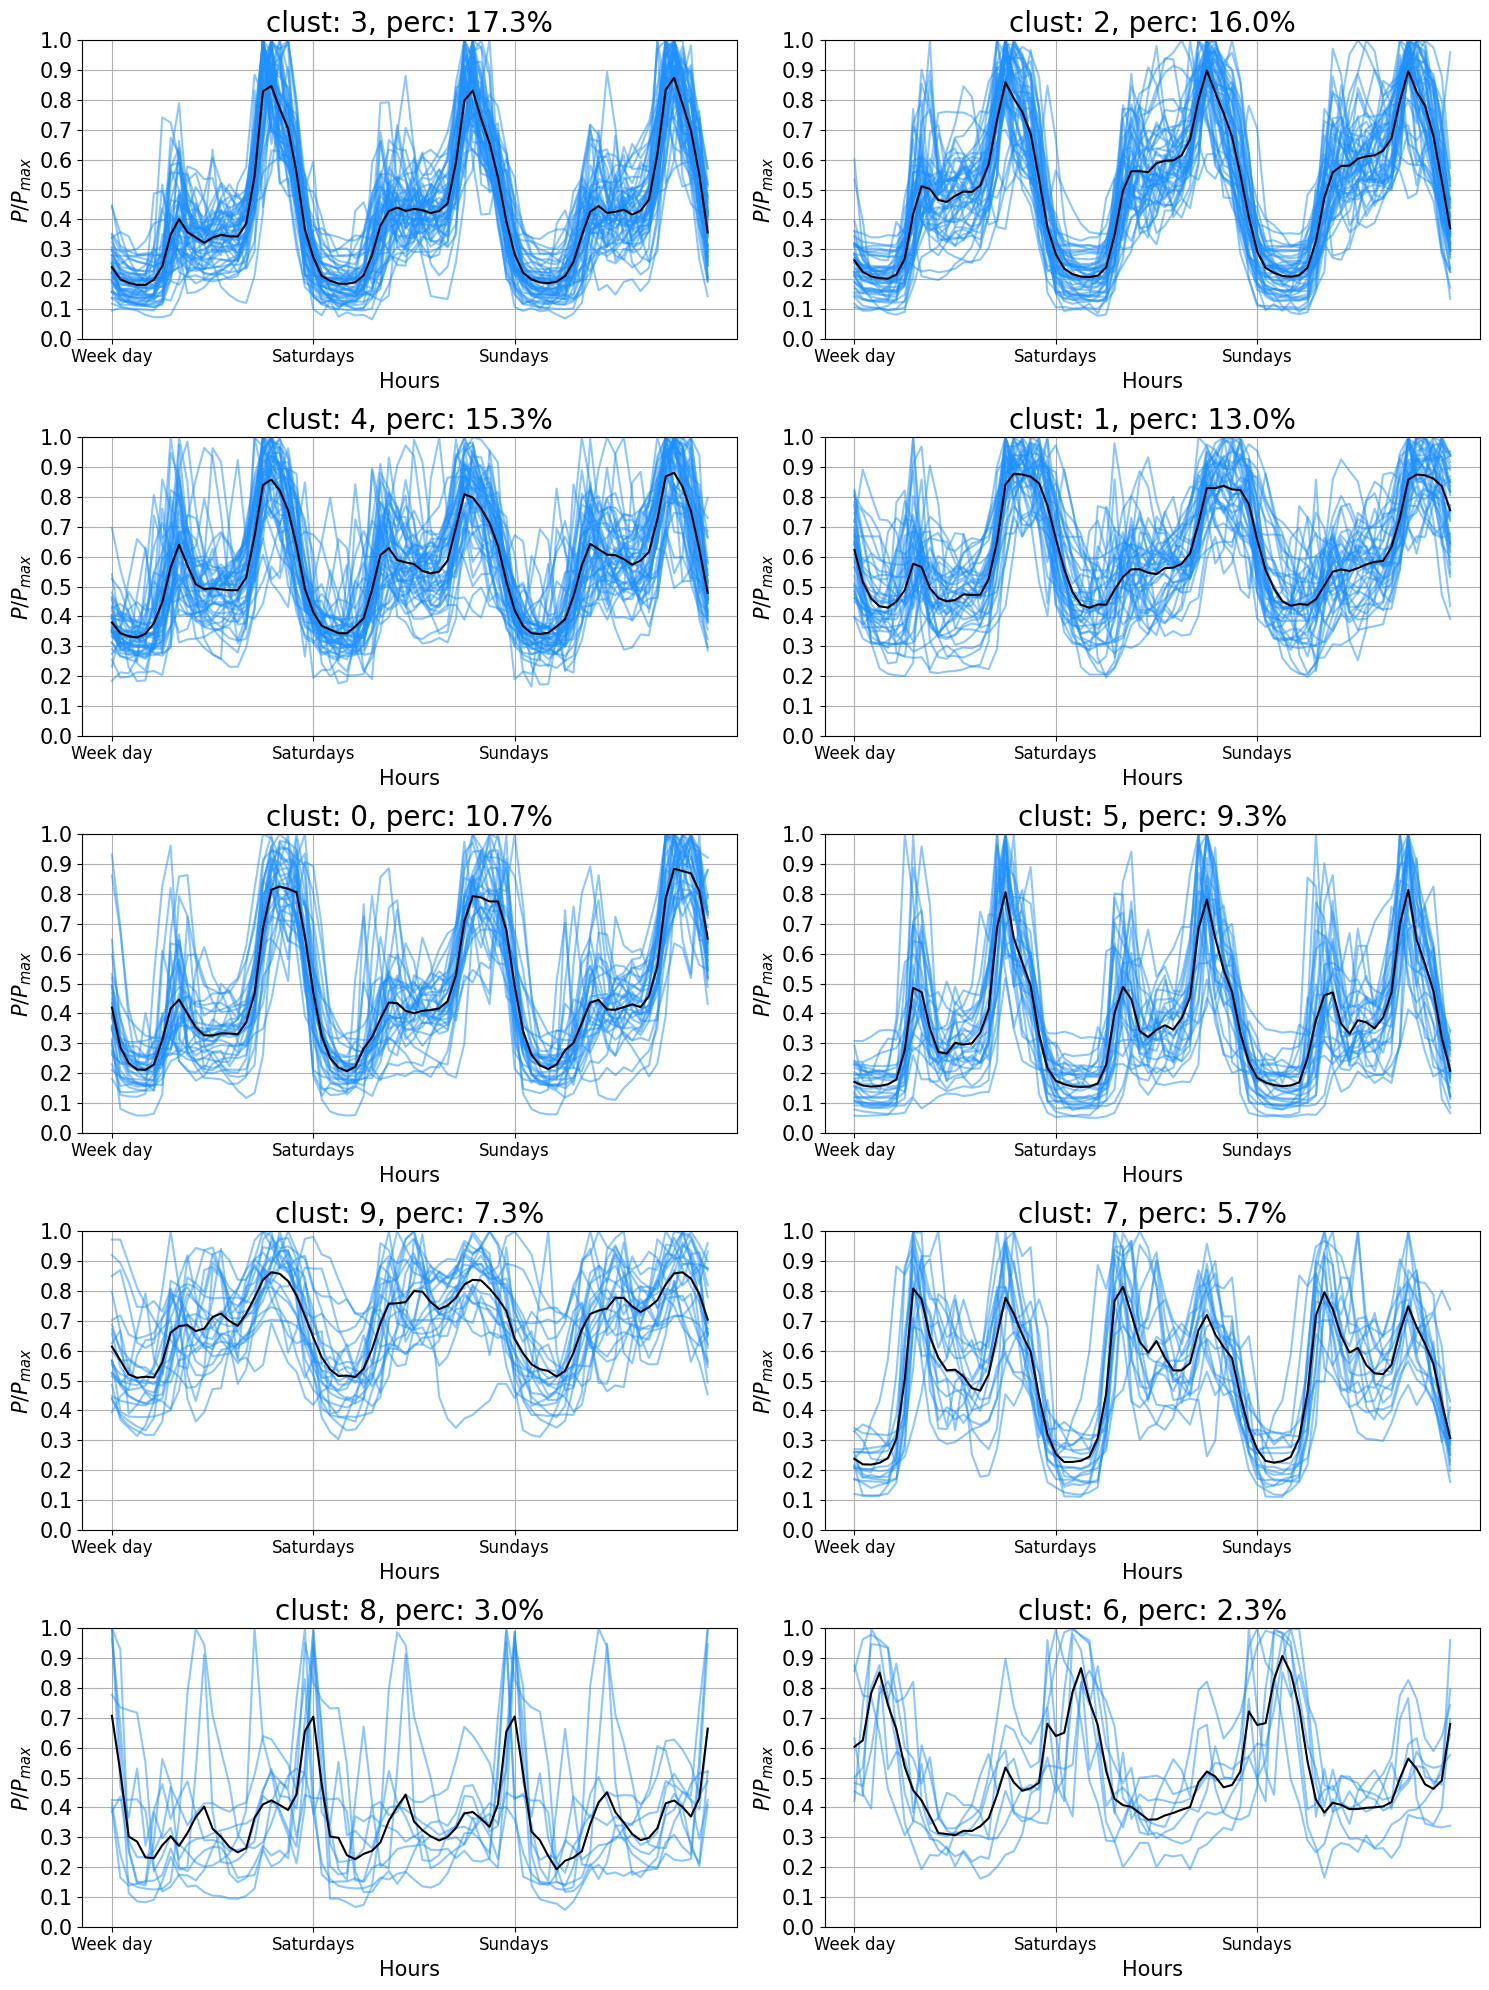

In [128]:
clust_gmm = pd.Series(gmm_labels, index=X_weekly_mean_norm.index)
plot_clustered_profiles(X_weekly_mean_norm, clust_gmm, n_cols=2, alpha=0.5)


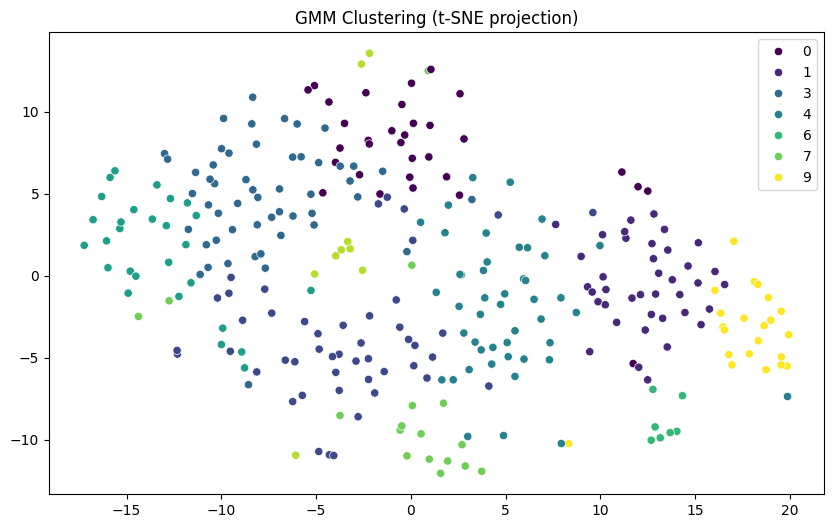

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you've already run .fit() and have 'gmm_labels'
plt.figure(figsize=(10, 6))
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], hue=gmm_labels, palette='viridis')
plt.title('GMM Clustering (t-SNE projection)')
plt.show()


# 5. Chosen Clustering Method: KMeans

**KMeans** achieves the best overall average rank across the four evaluation criteria, and this result holds consistently across different numbers of clusters:

- **Best Silhouette score** – consumers are well-matched to their own cluster relative to neighbouring clusters.
- **Highest Calinski-Harabasz score** – clusters are dense and well-separated.
- **Lowest Davies-Bouldin index** – least average similarity between each cluster and its nearest neighbour.
- **No noise** – every consumer is assigned to a cluster.

GMM is a close second with nearly identical metric values. Agglomerative (Ward) falls further behind on this dataset.

**Conclusion: KMeans is the recommended clustering method.**

In [130]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

X = X_weekly_mean_norm.to_numpy(dtype=float)

def centroid_rmse(X, labels):
    """Mean RMSE from each point to its cluster centroid."""
    unique = np.unique(labels)
    centroids = np.array([X[labels == c].mean(axis=0) for c in unique])
    idx = np.searchsorted(unique, labels)
    return np.sqrt(((X - centroids[idx]) ** 2).sum(axis=1)).mean()

methods = {
    "KMeans":        model.labels_,
    "Agglomerative": agglo_labels,
    "GMM":           gmm_labels,
}

rows = []
for name, labels in methods.items():
    n_clust = len(np.unique(labels))
    rmse = centroid_rmse(X, labels)
    sil  = silhouette_score(X, labels)
    ch   = calinski_harabasz_score(X, labels)
    dbs  = davies_bouldin_score(X, labels)
    rows.append({"Method": name, "Clusters": n_clust,
                 "Avg RMSE": rmse, "Silhouette": sil,
                 "Calinski-Harabasz": ch, "Davies-Bouldin": dbs})

metrics_df = pd.DataFrame(rows).set_index("Method")

rank_df = pd.DataFrame(index=metrics_df.index)
rank_df["r_rmse"] = metrics_df["Avg RMSE"].rank(ascending=True)
rank_df["r_sil"]  = metrics_df["Silhouette"].rank(ascending=False)
rank_df["r_ch"]   = metrics_df["Calinski-Harabasz"].rank(ascending=False)
rank_df["r_db"]   = metrics_df["Davies-Bouldin"].rank(ascending=True)
metrics_df["Avg rank"] = rank_df.mean(axis=1).round(2)

display(metrics_df.round(4).sort_values("Avg rank"))

,Clusters,Avg RMSE,Silhouette,Calinski-Harabasz,Davies-Bouldin,Avg rank
Method,,,,,,
KMeans,10,0.9675,0.1054,36.2060,1.8994,1.75
GMM,10,0.9661,0.1022,36.4446,1.9017,1.75
Agglomerative,10,0.9898,0.0943,33.3208,1.8040,2.50


In [131]:
# Re-run KMeans (best performing method) on normalised weekly profiles
n_clusters = 10
model_final = KMeans(n_clusters=n_clusters, random_state=42).fit(X_weekly_mean_norm.values)
clust_final = pd.Series(model_final.labels_, index=X_weekly_mean_norm.index, name="cluster")

# Compute Euclidean distance from each user to their cluster centroid
X = X_weekly_mean_norm.to_numpy(dtype=float)
dist_to_centroid = np.linalg.norm(X - model_final.cluster_centers_[clust_final.values], axis=1)

ranking_df = pd.DataFrame({
    "user_id":          X_weekly_mean_norm.index,
    "cluster":          clust_final.values,
    "dist_to_centroid": dist_to_centroid,
})

ranking_df = ranking_df.sort_values(["cluster", "dist_to_centroid"]).reset_index(drop=True)
ranking_df["rank_in_cluster"] = ranking_df.groupby("cluster").cumcount() + 1

display(ranking_df.head(20))

out_dir = os.path.join(base_dir, "clustering_results")
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, f"user_ids_sorted_by_cluster_{n_clusters}.csv")
ranking_df.to_csv(out_path, index=False)
print(f"Saved {len(ranking_df)} rows → {out_path}")

,user_id,cluster,dist_to_centroid,rank_in_cluster
0,user_259,0,0.498059,1
1,user_144,0,0.511676,2
2,user_271,0,0.513117,3
3,user_27,0,0.538069,4
4,user_5,0,0.558736,5
5,user_73,0,0.559576,6
6,user_216,0,0.599416,7
7,user_111,0,0.607320,8
8,user_173,0,0.609930,9
9,user_227,0,0.628357,10


Saved 300 rows → /Users/tomaz/Documents/Andraz/Household-RL/clustering_results/user_ids_sorted_by_cluster_10.csv
